<a href="https://colab.research.google.com/github/debarghya-IITB/Heart_Disease_Risk_Factor_Analysis/blob/main/heart_disease_risk_factor_analysis_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# For data manipulation
import pandas as pd
import numpy as np

# For statistical modeling and analysis
import statsmodels.api as sm

# For building a predictive model and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# For visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for plots
sns.set_style('whitegrid')

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler

In [6]:
# Load the data
path = 'https://raw.githubusercontent.com/debarghya-IITB/data_sets/refs/heads/main/framingham.csv'
df = pd.read_csv(path)

# See the first few rows
print(df.head().T)

# Get a summary of the data types and non-null values
print(df.info())

# Check for missing values in each column
print(df.isnull().sum())

# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

                      0       1       2       3      4
male               1.00    0.00    1.00    0.00    0.0
age               39.00   46.00   48.00   61.00   46.0
education          4.00    2.00    1.00    3.00    3.0
currentSmoker      0.00    0.00    1.00    1.00    1.0
cigsPerDay         0.00    0.00   20.00   30.00   23.0
BPMeds             0.00    0.00    0.00    0.00    0.0
prevalentStroke    0.00    0.00    0.00    0.00    0.0
prevalentHyp       0.00    0.00    0.00    1.00    0.0
diabetes           0.00    0.00    0.00    0.00    0.0
totChol          195.00  250.00  245.00  225.00  285.0
sysBP            106.00  121.00  127.50  150.00  130.0
diaBP             70.00   81.00   80.00   95.00   84.0
BMI               26.97   28.73   25.34   28.58   23.1
heartRate         80.00   95.00   75.00   65.00   85.0
glucose           77.00   76.00   70.00  103.00   85.0
TenYearCHD         0.00    0.00    0.00    1.00    0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0

In [7]:
df['TenYearCHD'].value_counts()

,count
TenYearCHD,
0,3596
1,644


Our data have high class imbalance so after feature selection, we should apply smote for class balancing.

In [8]:
# Identify column types
# Note: 'male' is binary, but we'll treat it as categorical for imputation.
categorical_cols = ['male', 'education', 'currentSmoker', 'BPMeds',
                    'prevalentStroke', 'prevalentHyp', 'diabetes']

# All other columns except the target are numerical
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['TenYearCHD']]

In [9]:
# Pipeline for numerical features: impute with mean
# We'll stick with median here as it's generally safer for health data, but you can swap for 'mean'
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

# Pipeline for categorical features: impute with mode
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [10]:
# Create the preprocessor object
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_cols),
        ('cat', cat_pipeline, categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (like our target 'TenYearCHD') untouched
)

# Apply the transformations to the dataframe
df_imputed = preprocessor.fit_transform(df)

# The output is a NumPy array, so let's convert it back to a DataFrame
# The order of columns might change, so we reconstruct it carefully
new_cols = numerical_cols + categorical_cols + ['TenYearCHD']
df_imputed = pd.DataFrame(df_imputed, columns=new_cols)

# Verify that there are no more missing values
print("Missing values after imputation:")
print(df_imputed.isnull().sum().any()) # Should be False
print("\nFirst 5 rows of cleaned data:")
print(df_imputed.head().T)

Missing values after imputation:
False

First 5 rows of cleaned data:
                      0       1       2       3      4
age               39.00   46.00   48.00   61.00   46.0
cigsPerDay         0.00    0.00   20.00   30.00   23.0
totChol          195.00  250.00  245.00  225.00  285.0
sysBP            106.00  121.00  127.50  150.00  130.0
diaBP             70.00   81.00   80.00   95.00   84.0
BMI               26.97   28.73   25.34   28.58   23.1
heartRate         80.00   95.00   75.00   65.00   85.0
glucose           77.00   76.00   70.00  103.00   85.0
male               1.00    0.00    1.00    0.00    0.0
education          4.00    2.00    1.00    3.00    3.0
currentSmoker      0.00    0.00    1.00    1.00    1.0
BPMeds             0.00    0.00    0.00    0.00    0.0
prevalentStroke    0.00    0.00    0.00    0.00    0.0
prevalentHyp       0.00    0.00    0.00    1.00    0.0
diabetes           0.00    0.00    0.00    0.00    0.0
TenYearCHD         0.00    0.00    0.00    1.00   

In [11]:
df_imputed.to_csv('cleaned_data.csv',index=False)

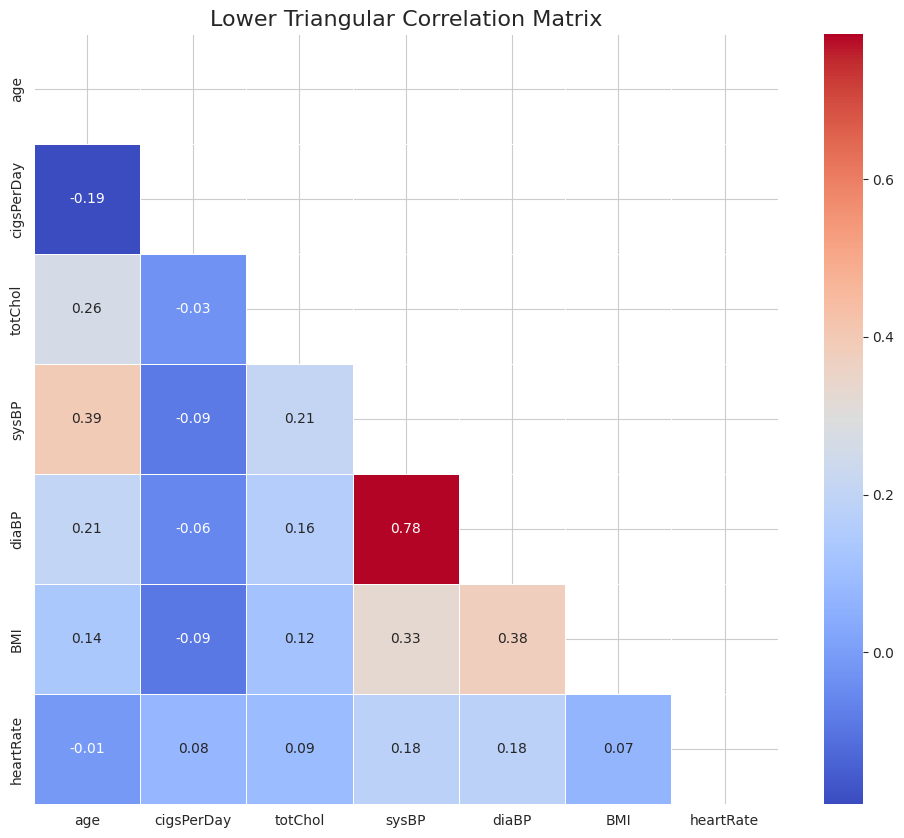

In [12]:


# --- 1. Define your numerical features ---
# The variable name is now 'numerical_cols'
numerical_cols = numerical_cols[:len(numerical_cols)-1]

# --- 2. Create a DataFrame with only the numerical features ---
# We'll use the main dataframe 'df' and select only these columns.
# It's good practice to check if the columns exist first.
existing_cols = [col for col in numerical_cols if col in df.columns]
numerical_df = df[existing_cols]


# --- 3. Calculate the correlation matrix ---
correlation_matrix = numerical_df.corr()

# --- 4. Plot the heatmap ---
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))


# --- Plot the heatmap with the mask ---
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    mask=mask,         # Apply the mask
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5
)
#
plt.title('Lower Triangular Correlation Matrix', fontsize=16)
plt.show()

Here sysBP & diaBP are highly correlated. But in Logistics Regression, there is an assumtion that the predictors should be independent... that's why we have to drop one of these two predictors. We drop sysBP as it has slightly more correlation with the other predictors than diaBP.

In [13]:
numerical_cols = [col for col in numerical_cols if col != 'sysBP']

df_imputed.drop(columns=['sysBP'],inplace=True)

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


# --- 1. Select the numerical columns and add a constant ---
# The VIF function requires a constant (intercept) in the design matrix.
X = df_imputed[numerical_cols]
X = add_constant(X)


# --- 2. Calculate VIF for each feature ---
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


# --- 3. Display the results ---
# We can ignore the VIF for the constant, as it's not a feature.
print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data[vif_data["feature"] != 'const'])

Variance Inflation Factor (VIF) for each feature:
      feature       VIF
1         age  1.150069
2  cigsPerDay  1.050714
3     totChol  1.097043
4       diaBP  1.244417
5         BMI  1.177647
6   heartRate  1.049182


All the VIFs are close to 1 so there is no multicollinearity.

In [15]:
# df_imputed is the final DataFrame from our last step
# Separate the features (X) from the target (y)
X = df_imputed.drop('TenYearCHD', axis=1)
y = df_imputed['TenYearCHD']

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

In [16]:
# 1. Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=7)

# 2. Apply SMOTE to the training data ONLY
smote = SMOTE(random_state=6)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the new, balanced class distribution of the training set
print("Original training set class distribution:")
print(y_train.value_counts())
print("\nResampled training set class distribution:")
print(y_train_resampled.value_counts())

Original training set class distribution:
TenYearCHD
0.0    2890
1.0     502
Name: count, dtype: int64

Resampled training set class distribution:
TenYearCHD
0.0    2890
1.0    2890
Name: count, dtype: int64


In [17]:
# Initialize and train the logistic regression model
model = LogisticRegression()
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original, un-resampled test set
predictions = model.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))


--- Model Evaluation ---
Confusion Matrix:
[[477 229]
 [ 61  81]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.68      0.77       706
         1.0       0.26      0.57      0.36       142

    accuracy                           0.66       848
   macro avg       0.57      0.62      0.56       848
weighted avg       0.78      0.66      0.70       848

